# ORCA Driver Testing

In [1]:
import pylablib.devices.DCAM as dcam

In [2]:
dcam.get_cameras_number()

2

In [8]:
camera = dcam.DCAMCamera(0)
camera.get_device_info()

TDeviceInfo(vendor='Hamamatsu', model='C9100-23B', serial_number='S/N: 000407', camera_version='1.21.00.D')

In [11]:
camera2 = dcam.DCAMCamera(1)
camera2.get_device_info()

TDeviceInfo(vendor='Hamamatsu', model='C10600-10B (ORCA-R2)', serial_number='S/N: 280187', camera_version='1.02.10.F')

In [12]:
camera.close()
camera2.close()

---

In [1]:
from pytweezer.experiment.motmaster_client import MotMasterClient
from pytweezer.drivers.orca import ORCACamera
from pytweezer.experiment.experiment_parameter_manager import ExpParameterManager
import pytweezer.phasemask as pm
import pytweezer.analysis as an
import numpy as np
import matplotlib.pyplot as plt

ExpParams = ExpParameterManager()

In [2]:
exp : MotMasterClient = MotMasterClient()
orca : ORCACamera = ORCACamera()

Rb MotMasterClient initialised.
ORCA camera initialised.


In [3]:
orca.dcam.get_device_info()

TDeviceInfo(vendor='Hamamatsu', model='C10600-10B (ORCA-R2)', serial_number='S/N: 280187', camera_version='1.02.10.F')

In [8]:
exp.set_save_toggle(False)
exp.set_run_until_stopped(False)
exp.set_motmaster_experiment("RbTweezerBasic2026_2")


orca.set_trigger_source("ext")
orca.set_external_exposure_mode()
#orca.set_sensitivity(10)
#orca.timeout = 60*5
#X0, Y0, WIDTH, HEIGHT = 110, 220, 256, 256
#orca.set_roi(X0, WIDTH, Y0, HEIGHT)

In [10]:
orca.dcam._list_attributes()

[DCAMAttribute(name='SENSOR MODE', kind=enum, id=4194832, min=1, max=1, unit=0),
 DCAMAttribute(name='READOUT SPEED', kind=int, id=4194576, min=1, max=2, unit=0),
 DCAMAttribute(name='COLORTYPE', kind=enum, id=4325664, min=1, max=1, unit=0),
 DCAMAttribute(name='BIT PER CHANNEL', kind=int, id=4325680, min=12, max=16, unit=0),
 DCAMAttribute(name='TRIGGER SOURCE', kind=enum, id=1048848, min=1, max=3, unit=0),
 DCAMAttribute(name='TRIGGER MODE', kind=enum, id=1049104, min=1, max=6, unit=0),
 DCAMAttribute(name='TRIGGER ACTIVE', kind=enum, id=1048864, min=1, max=3, unit=0),
 DCAMAttribute(name='TRIGGER POLARITY', kind=enum, id=1049120, min=1, max=2, unit=0),
 DCAMAttribute(name='TRIGGER TIMES', kind=int, id=1049152, min=1, max=4095, unit=0),
 DCAMAttribute(name='SENSOR COOLER FAN', kind=enum, id=2098000, min=1, max=2, unit=0),
 DCAMAttribute(name='LIGHT MODE', kind=enum, id=2097424, min=1, max=2, unit=0),
 DCAMAttribute(name='EXPOSURE TIME CONTROL', kind=enum, id=2031920, min=1, max=2, un

In [5]:
exp.set_iterations(1)
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 2.0, "tImgRepVVA1": 2.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})

{'ok': True,
 'command': 'call_interface',
 'method': 'start_motmaster_experiment',
 'state': 'accepted'}

Running background experiment...
Background images acquired...
Running image experiment...
Images acquired...
Mean pixel value: 0.022839646112351192 | Max pixel value: 15.099999999999994 | Min pixel value: -8.400000000000006


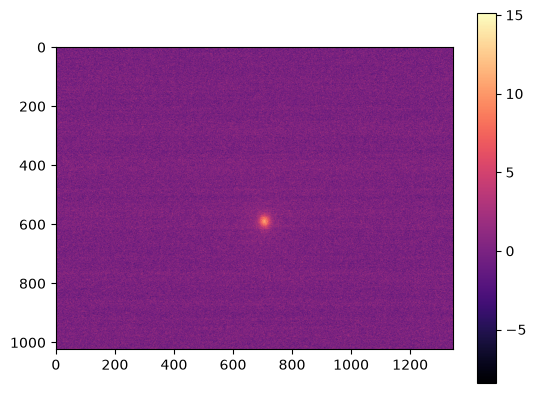

In [12]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
orca.setup_acquisition("snap", bg_it)
orca.start_acquisition()
print("Running background experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs_bg = orca.acquire_n_frames(bg_it)
print("Background images acquired...")

exp.set_iterations(img_it)
orca.setup_acquisition("snap", img_it)
orca.start_acquisition()
print("Running image experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs = orca.acquire_n_frames(img_it)
print("Images acquired...")
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma')
plt.colorbar()

print(f"Mean pixel value: {img_mean.mean()} | Max pixel value: {img_mean.max()} | Min pixel value: {img_mean.min()}")

In [13]:
orca.dcam.get_attribute_value("CONTRAST GAIN")

0

In [14]:
orca.dcam.set_attribute_value("CONTRAST GAIN", 10.0)

In [21]:
orca.dcam.get_attribute_value("contrast gain")

255

Running background experiment...
Background images acquired...
Running image experiment...
Images acquired...
Mean pixel value: 0.1390752883184524 | Max pixel value: 21.200000000000003 | Min pixel value: -10.700000000000003


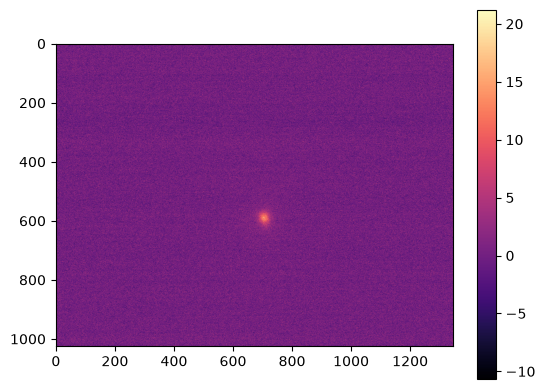

In [16]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
orca.setup_acquisition("snap", bg_it)
orca.start_acquisition()
print("Running background experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs_bg = orca.acquire_n_frames(bg_it)
print("Background images acquired...")

exp.set_iterations(img_it)
orca.setup_acquisition("snap", img_it)
orca.start_acquisition()
print("Running image experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs = orca.acquire_n_frames(img_it)
print("Images acquired...")
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma')
plt.colorbar()

print(f"Mean pixel value: {img_mean.mean()} | Max pixel value: {img_mean.max()} | Min pixel value: {img_mean.min()}")

In [17]:
orca.dcam.set_attribute_value("CONTRAST GAIN", 100.0)

Running background experiment...
Background images acquired...
Running image experiment...
Images acquired...
Mean pixel value: 0.05768621535528276 | Max pixel value: 61.900000000000006 | Min pixel value: -35.599999999999994


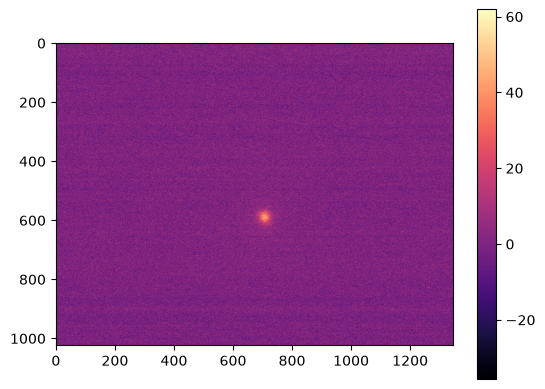

In [18]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
orca.setup_acquisition("snap", bg_it)
orca.start_acquisition()
print("Running background experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs_bg = orca.acquire_n_frames(bg_it)
print("Background images acquired...")

exp.set_iterations(img_it)
orca.setup_acquisition("snap", img_it)
orca.start_acquisition()
print("Running image experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs = orca.acquire_n_frames(img_it)
print("Images acquired...")
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma')
plt.colorbar()

print(f"Mean pixel value: {img_mean.mean()} | Max pixel value: {img_mean.max()} | Min pixel value: {img_mean.min()}")

In [19]:
orca.dcam.set_attribute_value("CONTRAST GAIN", 255)

Running background experiment...
Background images acquired...
Running image experiment...
Images acquired...
Mean pixel value: 0.3047953287760417 | Max pixel value: 136.1 | Min pixel value: -84.9


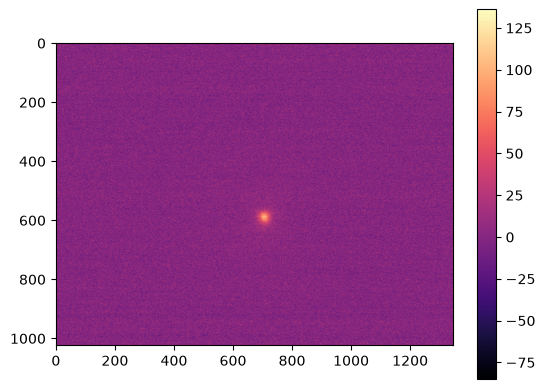

In [20]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
orca.setup_acquisition("snap", bg_it)
orca.start_acquisition()
print("Running background experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs_bg = orca.acquire_n_frames(bg_it)
print("Background images acquired...")

exp.set_iterations(img_it)
orca.setup_acquisition("snap", img_it)
orca.start_acquisition()
print("Running image experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs = orca.acquire_n_frames(img_it)
print("Images acquired...")
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma')
plt.colorbar()

print(f"Mean pixel value: {img_mean.mean()} | Max pixel value: {img_mean.max()} | Min pixel value: {img_mean.min()}")

In [27]:
orca.dcam.set_attribute_value("CONTRAST GAIN", 0)

Running background experiment...
Background images acquired...
Running image experiment...
Images acquired...
Mean pixel value: 0.3077808925083706 | Max pixel value: 70.6 | Min pixel value: -8.5


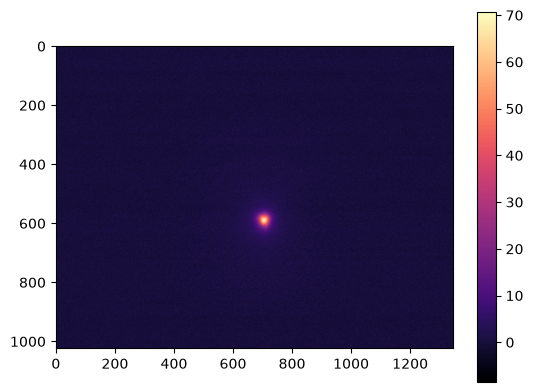

In [30]:
img_it = 10
bg_it = 2

exp.set_iterations(bg_it)
orca.setup_acquisition("snap", bg_it)
orca.start_acquisition()
print("Running background experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tMOTccValue": 0.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs_bg = orca.acquire_n_frames(bg_it)
print("Background images acquired...")

exp.set_iterations(img_it)
orca.setup_acquisition("snap", img_it)
orca.start_acquisition()
print("Running image experiment...")
exp.start_motmaster_experiment({"tMOTLoadRepVCO": ExpParams.get_parameter("tMOTLoadRepVCO"), "tMOTLoadCoolVCO": ExpParams.get_parameter("tMOTLoadCoolVCO"),
                                "tMOTLoadRepVVA": ExpParams.get_parameter("tMOTLoadRepVVA"), "tMOTLoadCoolVVA": ExpParams.get_parameter("tMOTLoadCoolVVA"), 
                                "tImgRepVCO1": ExpParams.get_parameter("rep_vco_resonance"), "tImgCoolVCO1": ExpParams.get_parameter("cool_vco_resonance"), 
                                "tDelay1": 1, "tMolassesDuration": 1, "tImgCoolVVA1": 1.0, "tImgRepVVA1": 1.0, "tDelay2": 1, 
                                "tTweezerExposure1":100, "tTweezerExposure2":100, "PatternLength": 60000, "tMOTLoadingDuration": 50000})
imgs = orca.acquire_n_frames(img_it)
print("Images acquired...")
img_mean = imgs.mean(axis=0) - imgs_bg.mean(axis=0)

plt.imshow(img_mean, cmap='magma')
plt.colorbar()

print(f"Mean pixel value: {img_mean.mean()} | Max pixel value: {img_mean.max()} | Min pixel value: {img_mean.min()}")